# Μέρος 1: Παρακολούθηση Προσώπου και Χεριών με Χρήση της Μεθόδου Οπτικής Ροής των Lucas-Kanade

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage, io
import os

## 1.1 Ανίχνευση Δέρματος Προσώπου και Χεριών

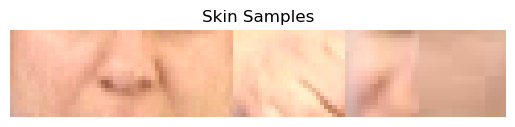

In [24]:
# Load skin samples and convert to YCbCr
mat = io.loadmat('part1_data/skinSamplesRGB.mat')
skinSamples = np.array(mat['skinSamplesRGB'])

plt.title('Skin Samples')
plt.imshow(skinSamples)
plt.axis('off')
plt.show()

skinSamples = cv2.cvtColor(skinSamples, cv2.COLOR_RGB2YCrCb)
del mat

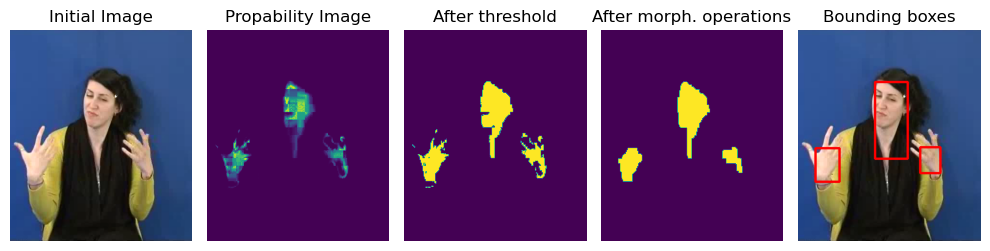

In [25]:
# Load first frame
imageRGB = cv2.imread('part1_data/1.png')
imageRGB = cv2.cvtColor(imageRGB, cv2.COLOR_BGR2RGB)
imageYCbCr = cv2.cvtColor(imageRGB, cv2.COLOR_RGB2YCrCb)
c = np.array([imageYCbCr[:,:,1].flatten(), imageYCbCr[:,:,2].flatten()])

# Calculate mean value and covariance matrix
Cb = skinSamples[:,:,1].flatten()
Cr = skinSamples[:,:,2].flatten()
mean_Cb = np.mean(Cb)
mean_Cr = np.mean(Cr)
mu = np.array([mean_Cb, mean_Cr])
sigma = np.cov(Cb, Cr)

# Calculate propability image
prob_image = stats.multivariate_normal(mean=mu, cov=sigma).pdf(c.T)
prob_image = prob_image.reshape(imageRGB.shape[0], imageRGB.shape[1])

# Apply threshold
_, prob_thres = cv2.threshold(prob_image, 0.0005, 1, cv2.THRESH_BINARY)

# Apply opening, then closing
open_kernel = np.ones((7, 7))
close_kernel = np.ones((20, 20), np.uint8)
prob_morph = cv2.morphologyEx(prob_thres, cv2.MORPH_OPEN, open_kernel)
prob_morph = cv2.morphologyEx(prob_morph, cv2.MORPH_CLOSE, close_kernel)
prob_morph = (prob_morph * 255).astype('uint8')

# Draw bounding boxes
image_out = imageRGB.copy()
_, contours, _ = cv2.findContours(prob_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 3)

# Plot steps
plt.figure(figsize=(10, 3))
plt.subplot(1,5,1)
plt.title('Initial Image')
plt.imshow(imageRGB)
plt.axis('off')
plt.subplot(1,5,2)
plt.title('Propability Image')
plt.imshow(prob_image)
plt.axis('off')
plt.subplot(1,5,3)
plt.title('After threshold')
plt.imshow(prob_thres)
plt.axis('off')
plt.subplot(1,5,4)
plt.title('After morph. operations')
plt.imshow(prob_morph)
plt.axis('off')
plt.subplot(1,5,5)
plt.title('Bounding boxes')
plt.imshow(image_out)
plt.axis('off')
plt.tight_layout()
plt.show()

del imageRGB, imageYCbCr, c, prob_image, prob_thres, prob_morph, image_out, contours

Compose final function:

In [26]:
def SkinDetect(image, mean, cov):
    # Convert to YCbCr
    imageYCbCr = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)

    # Calculate propability image
    c = np.array([imageYCbCr[:,:,1].flatten(), imageYCbCr[:,:,2].flatten()])
    prob_image = stats.multivariate_normal(mean, cov).pdf(c.T)
    prob_image = prob_image.reshape(image.shape[0], image.shape[1])

    # Apply threshold
    _, prob_thres = cv2.threshold(prob_image, 0.0005, 1, cv2.THRESH_BINARY)

    # Apply morphological operations
    open_kernel = np.ones((7, 7))
    close_kernel = np.ones((20, 20), np.uint8)
    prob_morph = cv2.morphologyEx(prob_thres, cv2.MORPH_OPEN, open_kernel)
    prob_morph = cv2.morphologyEx(prob_morph, cv2.MORPH_CLOSE, close_kernel)
    prob_morph = (prob_morph * 255).astype('uint8')

    # Draw bounding boxes
    _, contours, _ = cv2.findContours(prob_morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bounding_boxes = [cv2.boundingRect(contour) for contour in contours]
    return bounding_boxes

## 1.2 Παρακολούθηση Προσώπου και Χεριών

Κατασκευάσουμε τα κατάλληλα δεδομένα εισόδου. Καθώς τα πλαίσια της εκφώνησης είναι λανθασμένα, χρησιμοποιώ τη συνάρτηση SkinDetect(), διευρύνοντας τα παράθυρα

In [27]:
# Load first 2 frames
frame1 = cv2.imread('part1_data/1.png')
frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2 = cv2.imread('part1_data/2.png')
frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

# bounding_boxes = [[93, 272, 56, 83], [201, 270, 56, 83], [154, 102, 67, 115]] #left hand, right hand, head
bounding_boxes = SkinDetect(frame1, mu, sigma)
enlarge = [-10, -10, +20, +20]

# Work with two frames of the left hand
x, y, w, h = np.array(bounding_boxes[0]) + np.array(enlarge)
frame1 = frame1[y:y+h, x:x+w]
frame2 = frame2[y:y+h, x:x+w]

# Convert to grayscale
frame1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
frame2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

# Detect corners
corners = cv2.goodFeaturesToTrack(frame2, maxCorners=100, qualityLevel=0.01, minDistance=10)

Υλοποιούμε τη συνάρτηση

(-0.5, 69.5, 89.5, -0.5)

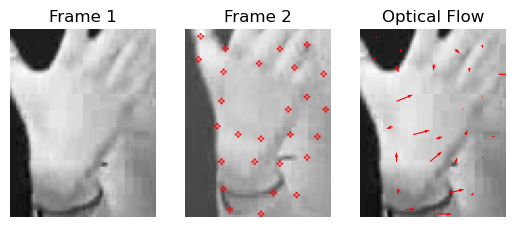

In [28]:
def LucasKanade(I1, I2, features, rho, epsilon, d_x0, d_y0):
    # Assert frames are on grayscale
    assert len(I1.shape) == 2
    assert len(I2.shape) == 2

    # Normalize images
    I1 = I1/255
    I2 = I2/255

    d = [[],[]]
    x_0, y_0 = np.meshgrid(np.arange(I1.shape[1]), np.arange(I1.shape[0]))
    dIx = np.diff(I1, axis=1)
    dIy = np.diff(I1, axis=0)

    for feature in features:
        x, y = feature.ravel()
        x = int(x)
        y = int(y)
        d_x = d_x0
        d_y = d_y0
        
        for i in range(100):
            # Calculate shifted images
            I1_d = ndimage.map_coordinates(I1,[y_0+d_y, x_0+d_x], order=1)
            dIx_d = ndimage.map_coordinates(dIx,[y_0+d_y, x_0+d_x], order=1)
            dIy_d = ndimage.map_coordinates(dIy,[y_0+d_y, x_0+d_x], order=1)

            # Calculate helper matrices
            A1 = dIx_d
            A2 = dIy_d
            E = I2 - I1_d
            del I1_d, dIx_d, dIy_d
            mat1_1 = cv2.GaussianBlur(A1@A1.T, (3*rho,3*rho), rho)+ epsilon
            mat1_12 = cv2.GaussianBlur(A1@A2.T, (3*rho,3*rho), rho)
            mat1_2 = cv2.GaussianBlur(A2@A2.T, (3*rho,3*rho), rho)+ epsilon
            mat2_1 = cv2.GaussianBlur(A1@E.T, (3*rho,3*rho), rho)
            mat2_2 = cv2.GaussianBlur(A2@E.T, (3*rho,3*rho), rho)
            del A1, A2, E
            mat1 = np.array([[mat1_1[y, x], mat1_12[y, x]],
                            [mat1_12[y, x], mat1_2[y, x]]])
            mat2 = np.array([[mat2_1[y, x]],
                            [mat2_2[y, x]]])
            del mat1_1, mat1_12, mat1_2, mat2_1, mat2_2

            # Calculate d_i+1
            u = np.linalg.inv(mat1)@mat2
            d_x += u[0,0]
            d_y += u[1,0]

            # Convergence criterion
            if abs(u[0,0]) < 0.001 and abs(u[1,0]) < 0.001:
                break

        d[0].append(d_x)
        d[1].append(d_y)

    d = np.array(d)
    return d

# Test function
[d_x, d_y] = LucasKanade(frame1, frame2, corners, rho=1, epsilon=0.1, d_x0=1, d_y0=1) #rho=[1,5], epsilon=[0.01, 0.1]

# Create plot images
frame2_corners = frame2.copy()
frame2_corners = cv2.cvtColor(frame2_corners, cv2.COLOR_GRAY2RGB)
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(frame2_corners, (int(x), int(y)), 1, (255, 0, 0))
x, y = zip(*[corner.ravel() for corner in corners])

# Plot the images
plt.subplot(1,3,1)
plt.imshow(frame1, cmap='gray')
plt.title('Frame 1')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(frame2_corners)
plt.axis('off')
plt.title('Frame 2')
plt.subplot(1,3,3)
plt.title("Optical Flow")
plt.imshow(frame1, cmap='gray')
plt.quiver(x, y, -d_x, -d_y, angles='xy', color='r')
plt.axis('off')

Υλοποιούμε τη συνάρτηση υπολογισμού μέσης ροής

In [29]:
def displ(d_x, d_y, method='threshold'):
    if method=='threshold':
        threshold = 3
        d = np.array([d_x, d_y])
        mean_energy = np.mean(np.linalg.norm(d, axis=0)**2)
        criterion = (np.abs(np.linalg.norm(d, axis=0)**2 - mean_energy) < threshold*mean_energy)
        d = d[:, criterion]
        return np.mean(d[0]), np.mean(d[1])
    elif method=='mean':
        return np.mean(d_x), np.mean(d_y)
    else:
        return None
    
# Test function
[displ_x, displ_y] = displ(d_x, d_y, method='threshold')
displ_x, displ_y

(-9.205345724577768, 2.922911834155445)

Εφαρμόζουμε όλα τα παραπάνω σε ολόκληρη την ακολουθία εικόνων

In [30]:
# # Load first 2 frames
# frame1 = cv2.imread('part1_data/1.png')
# frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
# frame2 = cv2.imread('part1_data/2.png')
# frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

# # Find initial bounding boxes
# bounding_boxes = SkinDetect(frame1, mu, sigma)
# enlarge = [-10, -10, +20, +20]
# bounding_boxes = np.array(bounding_boxes) + np.array(enlarge)

# # Draw bounding boxes and optical flow
# image_out = frame1.copy()
# for box in bounding_boxes:
#     x, y, w, h = box
#     cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
# if not os.path.exists('part1_output/1_2_2'):
#     os.makedirs('part1_output/1_2_2')
# image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
# cv2.imwrite('part1_output/1_2_2/1.png', image_out)

# # Find optical flow for each bounding box, on each frame
# i=1
# while True:
#     # Load first 2 frames
#     frame1 = cv2.imread(f'part1_data/{i}.png')
#     frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
#     frame2 = cv2.imread(f'part1_data/{i+1}.png')
#     if frame2 is None: break
#     frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
#     image_out = frame2.copy()

#     for box in bounding_boxes:
#         # Select frame
#         x, y, w, h = box
#         frame1_box = frame1[y:y+h, x:x+w]
#         frame2_box = frame2[y:y+h, x:x+w]

#         # Convert to grayscale
#         frame1_box = cv2.cvtColor(frame1_box, cv2.COLOR_RGB2GRAY)
#         frame2_box = cv2.cvtColor(frame2_box, cv2.COLOR_RGB2GRAY)

#         # Detect corners
#         corners = cv2.goodFeaturesToTrack(frame2_box, maxCorners=100, qualityLevel=0.01, minDistance=10)

#         # Run Lucas-Kanade
#         [d_x, d_y] = LucasKanade(frame1_box, frame2_box, corners, rho=1, epsilon=0.1, d_x0=1, d_y0=1) #rho=[1,5], epsilon=[0.01, 0.1]

#         # Calculate mean flow
#         [displ_x, displ_y] = displ(d_x, d_y, method='threshold')

#         # Update bounding box
#         box -= np.array([int(displ_x), int(displ_y), 0, 0])
#         box[box<0] = 0

#         # Draw new bounding box and optical flow
#         x, y, w, h = box
#         cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
#         x, y = x+(w//2), y+(h//2)
#         cv2.arrowedLine(image_out, (x, y), (int(x-displ_x), int(y-displ_y)), (255, 0, 0), 1)

#     # Save image
#     image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
#     cv2.imwrite(f'part1_output/1_2_2/{i+1}.png', image_out)

#     print(f"frame {i+1} done")
#     i+=1

In [31]:
def MultiScaleLucasKanade(I1, I2, features, rho, epsilon, d_x0, d_y0, num_levels=3):
    # Create Gaussian pyramids
    pyramid1 = [I1]
    pyramid2 = [I2]
    for i in range(num_levels - 1):
        pyramid1.append(cv2.pyrDown(pyramid1[i]))
        pyramid2.append(cv2.pyrDown(pyramid2[i]))

    # Initialize displacement vectors
    num_features = len(features) if features is not None else 0
    d_x, d_y = np.zeros((num_levels, num_features)), np.zeros((num_levels, num_features))

    # Apply Lucas-Kanade for each level
    for i in range(num_levels - 1, -1, -1):
        # Scale features
        scaled_features = features / (2 ** i)

        # Apply Lucas-Kanade
        d_x_i, d_y_i = LucasKanade(pyramid1[i], pyramid2[i], scaled_features, d_x0=d_x0, d_y0=d_y0, rho=rho, epsilon=epsilon)

        # Scale d accordingly
        d_x[i] = d_x_i * 2**i
        d_y[i] = d_y_i * 2**i

        # Next d_0 will be the current d
        d_x0, d_y0 = displ(d_x_i, d_y_i, method='threshold')

        # Plot frame with features
        # plt.subplot(1, num_levels, i+1)
        # frame = pyramid1[i].copy()
        # frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
        # for feature in scaled_features:
        #     x, y = feature.ravel()
            # cv2.circle(frame, (int(x), int(y)), 0, (255, 0, 0))
        # x, y = zip(*[feature.ravel() for feature in scaled_features])
        # plt.imshow(frame)
        # plt.title(f"Level {i+1}")
        # plt.quiver(x, y, -d_x[i], -d_y[i], angles='xy', color='r')
    # return np.mean(d_x, axis=0), np.mean(d_y, axis=0)
    return d_x[0], d_y[0]

Δοκιμάζουμε τον πολυκλιμακωτό Lucas-Kanade σε 2 frames

-18.50512994281269 6.390495721074294


(-0.5, 69.5, 89.5, -0.5)

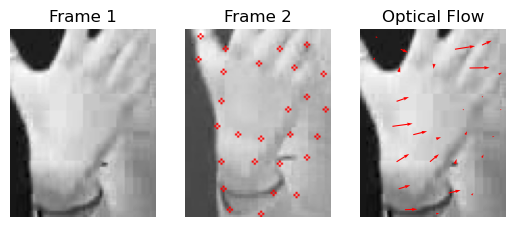

In [32]:
# Load first 2 frames
frame1 = cv2.imread('part1_data/1.png')
frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2 = cv2.imread('part1_data/2.png')
frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

# bounding_boxes = [[93, 272, 56, 83], [201, 270, 56, 83], [154, 102, 67, 115]] #left hand, right hand, head
bounding_boxes = SkinDetect(frame1, mu, sigma)
enlarge = [-10, -10, +20, +20]

# Work with two frames of the left hand
x, y, w, h = np.array(bounding_boxes[0]) + np.array(enlarge)
frame1 = frame1[y:y+h, x:x+w]
frame2 = frame2[y:y+h, x:x+w]

# Convert to grayscale
frame1 = cv2.cvtColor(frame1, cv2.COLOR_RGB2GRAY)
frame2 = cv2.cvtColor(frame2, cv2.COLOR_RGB2GRAY)

# Detect corners
corners = cv2.goodFeaturesToTrack(frame2, maxCorners=100, qualityLevel=0.01, minDistance=10)

# Test function
[d_x, d_y] = MultiScaleLucasKanade(frame1, frame2, corners, rho=1, epsilon=0.1, d_x0=1, d_y0=1, num_levels=3) #rho=[1,5], epsilon=[0.01, 0.1]

# Create plot images
frame2_corners = frame2.copy()
frame2_corners = cv2.cvtColor(frame2_corners, cv2.COLOR_GRAY2RGB)
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(frame2_corners, (int(x), int(y)), 1, (255, 0, 0))
x, y = zip(*[corner.ravel() for corner in corners])

# Print overall displacement
[displ_x, displ_y] = displ(d_x, d_y, method='threshold')
print(displ_x, displ_y)

# Plot the images
plt.subplot(1,3,1)
plt.imshow(frame1, cmap='gray')
plt.title('Frame 1')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(frame2_corners)
plt.axis('off')
plt.title('Frame 2')
plt.subplot(1,3,3)
plt.title("Optical Flow")
plt.imshow(frame1, cmap='gray')
plt.quiver(x, y, -d_x, -d_y, angles='xy', color='r')
plt.axis('off')

Δοκιμάζουμε τον πολυκλιμακωτό Lucas-Kanade σε όλα τα frames

In [34]:
# Load first 2 frames
frame1 = cv2.imread('part1_data/1.png')
frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2 = cv2.imread('part1_data/2.png')
frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

# Find initial bounding boxes
bounding_boxes = SkinDetect(frame1, mu, sigma)
enlarge = [-10, -10, +20, +20]
bounding_boxes = np.array(bounding_boxes) + np.array(enlarge)

# Draw bounding boxes and optical flow
image_out = frame1.copy()
for box in bounding_boxes:
    x, y, w, h = box
    cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
if not os.path.exists('part1_output/1_2_3'):
    os.makedirs('part1_output/1_2_3')
image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
cv2.imwrite('part1_output/1_2_3/1.png', image_out)

# Find optical flow for each bounding box, on each frame
i=1
while True:
    # Load first 2 frames
    frame1 = cv2.imread(f'part1_data/{i}.png')
    frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
    frame2 = cv2.imread(f'part1_data/{i+1}.png')
    if frame2 is None: break
    frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
    image_out = frame2.copy()

    for box in bounding_boxes:
        # Select frame
        x, y, w, h = box
        frame1_box = frame1[y:y+h, x:x+w]
        frame2_box = frame2[y:y+h, x:x+w]

        # Convert to grayscale
        frame1_box = cv2.cvtColor(frame1_box, cv2.COLOR_RGB2GRAY)
        frame2_box = cv2.cvtColor(frame2_box, cv2.COLOR_RGB2GRAY)

        # Detect corners
        corners = cv2.goodFeaturesToTrack(frame2_box, maxCorners=100, qualityLevel=0.01, minDistance=10)

        # Run Lucas-Kanade
        [d_x, d_y] = MultiScaleLucasKanade(frame1_box, frame2_box, corners, rho=1, epsilon=0.1, d_x0=1, d_y0=1, num_levels=3) #rho=[1,5], epsilon=[0.01, 0.1]

        # Calculate mean flow
        [displ_x, displ_y] = displ(d_x, d_y, method='threshold')

        # Update bounding box
        box -= np.array([int(displ_x), int(displ_y), 0, 0])
        box[box<0] = 0

        # Draw new bounding box and optical flow
        x, y, w, h = box
        cv2.rectangle(image_out, (x, y), (x+w, y+h), (255, 0, 0), 2)
        x, y = x+(w//2), y+(h//2)
        cv2.arrowedLine(image_out, (x, y), (int(x-displ_x), int(y-displ_y)), (255, 0, 0), 1)

    # Save image
    image_out = cv2.cvtColor(image_out, cv2.COLOR_RGB2BGR)
    cv2.imwrite(f'part1_output/1_2_3/{i+1}.png', image_out)

    print(f"frame {i+1} done")
    i+=1

frame 2 done
frame 3 done
frame 4 done


KeyboardInterrupt: 